In [ ]:
pip install qiskit qiskit-aer qiskit-ibm-runtime pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 985.4 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 8.6 MB/s eta 0:00:00
  Created wheel

**Overview:** This notebook covers how to convert between QASM3 and qiskit, it covers different import and export options and errors that might happpen during conversion.

In [ ]:
from qiskit import QuantumCircuit
from qiskit.qasm3 import dump, dumps,load,loads,loads_experimental
from qiskit.qasm3 import Exporter, QASM3ExporterError, QASM3ImporterError
from qiskit.providers.fake_provider import GenericBackendV2

## Objective : Interpret QASM3 language and inter-convert between qiskit and QASM3

Qiskit provides tools to export quantum circuits to QASM3 format and import QASM3 files back into Qiskit circuits.


### Exporting to QASM 3

#### Export Methods

* **`dump()`**: Export circuit to a file
* **`dumps()`**: Export circuit to an Open QASM3 string

In [ ]:
# Example export to file and string
# A file will be created in the current directory named 'sample_qasm.txt'

# Create a simple circuit
qc = QuantumCircuit(2,2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])

# Export to string
qasm_str = dumps(qc)
print("QASM3 String\n")
print(qasm_str)

# Export to file
with open("sample_qasm.txt", "w") as f:
  dump(qc, f)

QASM3 String

OPENQASM 3.0;
include "stdgates.inc";
bit[2] c;
qubit[2] q;
h q[0];
cx q[0], q[1];
c[0] = measure q[0];
c[1] = measure q[1];



#### Exporter Class

It can be used to customize the export process.

**Parameters**:
* **`includes`**: List of files to include (default: `["stdgates.inc"]`)
* **`basis_gates`**: Limit to specific gate set for hardware compatibility
* **`disable_constants`**: Disable constant folding optimizations
* **`alias_classical_registers`**: Use aliases for classical registers
* **`allow_aliasing`**: Allow use of `let` statements for qubit aliasing
* **`indent`**: String used for indentation (default: "  ")
* **`experimental`**: Enable experimental features
* **`annotation_handlers`**: Custom handlers for circuit annotations

In [ ]:
# Example with Exporeter class

qc = QuantumCircuit(3)
qc.h(0)
qc.rx(1.57, 1) # π/2 rotation

exporter = Exporter(
    # Don't include stdgates.inc
    includes=[],
    # Limit to specific gates
    basis_gates=["h", "rx"],
    # 4-space indentation
    indent="    ",
    allow_aliasing=True
)

# Export with custom exporter
qasm_str = exporter.dumps(qc)
print(qasm_str)

OPENQASM 3.0;
qubit[3] q;
h q[0];
rx(1.57) q[1];



#### QASM3ExporterError

The exporter raises `QASM3ExporterError` when it encounters unsupported features.

In [ ]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
# invalid use to test error handling
backend = GenericBackendV2(2)
exporter = Exporter(basis_gates=backend.operation_names)

try:
  qasm_str = exporter.dumps(qc)
  print(f'Export success : {qasm_str}')
except QASM3ExporterError as e:
  print(f'Export failed: {e}')

Export failed: "Cannot use 'reset' as a basis gate for the reason in the prior exception. Consider renaming the gate if needed, or omitting this basis gate if not."


#### Experimental Features

Access experimental features through `ExperimentalFeatures`.

### Importing from QASM 3

#### Import Methods

* **`load()`**: Import circuit from a file
* **`loads()`**: Import circuit from a string


**Note:**
package qiskit_qasm3_import must be installed. This can be done using
```pip install qiskit_qasm3_import```

In [ ]:
pip install qiskit_qasm3_import

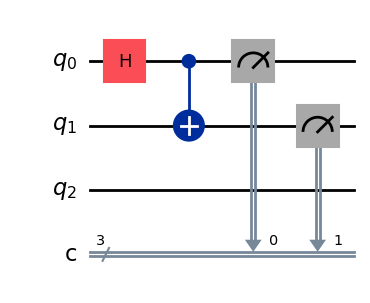

In [ ]:
# Example import from QASM3 string
qasm_code = """
OPENQASM 3.0;
include "stdgates.inc";

qubit[3] q;
bit[3] c;

h q[0];
cx q[0], q[1];

c[0] = measure q[0];
c[1] = measure q[1];
"""

# Import from string
circuit = loads(qasm_code)

circuit.draw("mpl")

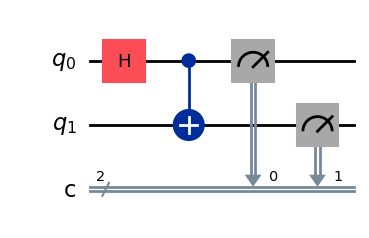

In [ ]:
# Example Import from file
circuit = load("sample_qasm.txt")
circuit.draw('mpl')

#### QASM3ImporterError

The importer raises `QASM3ImoporterError` when it encounters unsupported features.

In [ ]:
# Invalid QASM3 code
invalid_qasm = """
OPENQASM 3.0;
include "stdgates.inc";
qubit q;
rh q; // unknown gate
"""

try:
  circuit = loads(invalid_qasm)
except QASM3ImporterError as e:
  print(f'Import failed: {e}')


Import failed: "5,0: gate 'rh' is not defined."


#### Experimental Import Interface

Experimental Rust-based importer that is much faster.

##### Import Methods

* **`load_experimental()`**: Import circuit from a file
* **`loads_experimental()`**: Import circuit from a string

/usr/local/lib/python3.12/dist-packages/qiskit/qasm3/__init__.py:459: ExperimentalWarning: This is an experimental native version of the OpenQASM 3 importer. Beware that its interface might change, and it might be missing features.
  warnings.warn(


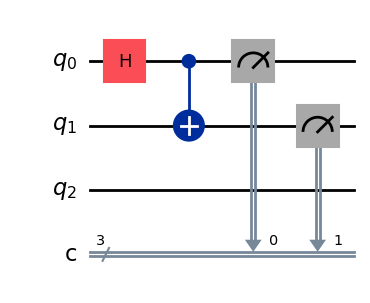

In [ ]:
# Example import from QASM3 string
qasm_code = """
OPENQASM 3.0;
include "stdgates.inc";

qubit[3] q;
bit[3] c;

h q[0];
cx q[0], q[1];

c[0] = measure q[0];
c[1] = measure q[1];
"""

# Import from string
circuit = loads_experimental(qasm_code)

circuit.draw("mpl")

#QASM3 with Qiskit SDK

## Objective : Interoperate different versions of OpenQASM with Qiskit

### Import QASM3 file into qiskit


Qiskit can import OpenQASM 3.0 programs using the `loads()` function for strings or `load()` for files.

Importing to Qiskit supports the following features

- Basic quantum gates and circuits
- Classical control flow (if/while)
- Custom gate definitions
- Parameterized circuits
- Measurement and reset operations

Check https://quantum.cloud.ibm.com/docs/en/guides/qasm-feature-table for a more detailed view on supported features.

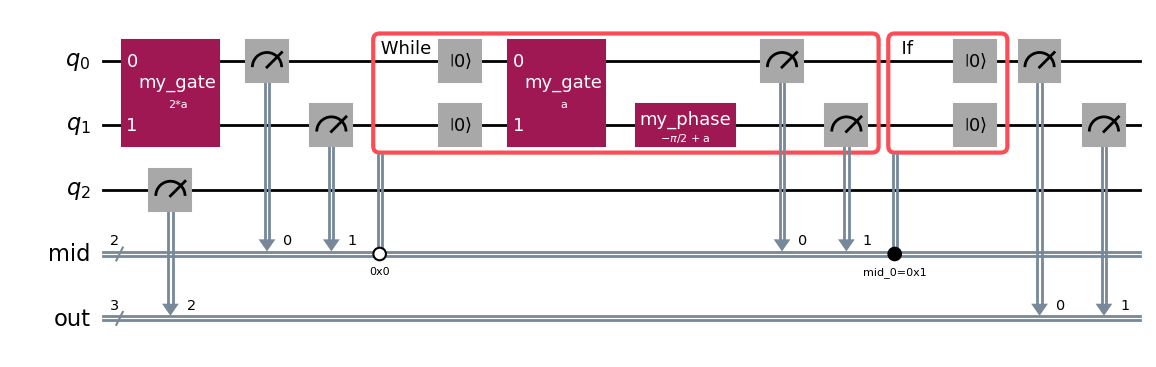

In [ ]:
# Example of importing a complex OpenQASM 3.0 program into Qiskit
program = """
OPENQASM 3.0;

include "stdgates.inc";

input float[64] a;
qubit[3] q;
bit[2] mid;
bit[3] out;

let aliased = q[0:1];

gate my_gate(a) c, t {
   gphase(a/2);
   ry(a) c;
   cx c, t;
}

gate my_phase(a) c {
   // This line caused a parsing error as gphase is a global phase instruction
   // and cannot be directly modified by ctrl @ inv and applied to a specific qubit.
   // ctrl @ inv @gphase(a) c;
}

my_gate(a*2) aliased[0], q[{1, 2}][0];
measure q[0] -> mid[0];
measure q[1] -> mid[1];

while (mid == "00"){
   reset q[0];
   reset q[1];
   my_gate(a) q[0], q[1];
   my_phase(a - pi/2) q[1];
   mid[0] = measure q[0];
   mid[1] = measure q[1];
}

if (mid[0]) {
   let inner_alias = q[{0, 1}];
   reset inner_alias;
}

out = measure q;

"""

circuit = loads(program)
circuit.draw("mpl")

### Export to QASM3


Qiskit can export circuits to OpenQASM 3.0 format using `dumps()` for strings or `dump()` for files.

Exporintg to QASM3 supports the following features:

- Converts Qiskit circuits to standard QASM3 format
- Supports parameterized circuits
- Can include custom gate decompositions
- Compatible with IBM Quantum Runtime API

In [ ]:
# Exporting a Qiskit QuantumCircuit to a String in OpenQASM 3.0 format
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

dumps(qc)

'OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[2] meas;\nqubit[2] q;\nh q[0];\ncx q[0], q[1];\nbarrier q[0], q[1];\nmeas[0] = measure q[0];\nmeas[1] = measure q[1];\n'

In [ ]:
# Exporting a Qiskit QuantumCircuit to a File in OpenQASM 3.0 format
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

f = open("sample_qasm.txt", "w")
dump(qc, f)
f.close()

#  Qiskit Runtime Rest API

**Overview:** This notebook covers how to use and interact with qiskit runtime core rest APIs like authentication, job submission, results retrieval and session managament.


In [ ]:
import requests, json

## Objective 1 : Interact with Qiskit IBM Runtime REST API

The Qiskit Runtime REST APIs provides programmatic access to IBM Quantum systems, allowing you to:

* **Run circuits** on quantum processors (QPUs)
* **Manage jobs and sessions** with the abiltiy to submit, delete , cancel jobs and retrieve results
* **Get information** about quantum processors, service instances, workloads, accounts and usage details


### Authentication

To use the Qiskit Runtime REST API, you need:
1. **IBM Cloud API Key**: From your IBM Cloud account
2. **IBM Quantum Instance CRN**: From your Quantum service instance

The authentication flow:
1. Exchange API key for IAM token
2. Use IAM token + Instance CRN for API requests

In [ ]:
url = 'https://iam.cloud.ibm.com/identity/token'
# Your IBM Cloud API key
api_key="v599YwyyD31O8-qPR_9ecdHoQjWyfmkdjGifgmP2Folk"

data = f'grant_type=urn:ibm:params:oauth:grant-type:apikey&apikey={api_key}'
response = requests.post(url, data=data)

# Bearer token to authorize requests to the REST API
if response.status_code == 200:
    print(f'Access token obtained successfully')
    bearer_token = response.json()['access_token']
else:
    print(f'Error obtaining bearer token:{response.status_code}, {response.text}')
    bearer_token = None

Access token obtained successfully


### Get available Backends

The example below shows how you can retrieve available backends for your account.

In [ ]:
reqUrl = "https://quantum.cloud.ibm.com/api/v1/backends"
# Service CRN of your IBM Quantum instance
service_CRN = "crn:v1:bluemix:public:quantum-computing:us-east:a/10a28aa5df454bab96a9b4b215b9974f:e4cd8cb3-96e8-4594-bea6-5129384d172a::"

headerList = {
    "Accept" : "application/json",
    "Authorization":f"Bearer {bearer_token}",
    "Service-CRN" : f"{service_CRN}",
    "IBM-API-Version":"2025-05-01"
}

payload = " "
response = requests.request("GET", reqUrl, data=payload, headers=headerList)

if response.status_code == 200:
    print(f'Available backends are: ')
    print(response.json())
    # Selecting the first backend from the list
    backend = response.json()['devices'][0]['name']
else:
    print(f'Error obtaining backends: {response.status_code}, {response.text}')
    backend = None

Available backends are: 
{'devices': [{'name': 'ibm_fez', 'status': {'name': 'paused', 'reason': 'maintenance'}, 'qubits': 156, 'clops': {'type': 'hardware', 'value': 320000}, 'processor_type': {'family': 'Heron', 'revision': '2'}, 'queue_length': 2176, 'performance_metrics': {'two_q_error_best': {'gate': 'cz', 'qubits': [131, 132], 'unit': '', 'value': 0.0013816196}, 'two_q_error_layered': {'unit': '', 'value': 0.004134141}, 'two_q_error_median': {'unit': '', 'value': 0.0027383626}, 'readout_error_median': {'unit': '', 'value': 0.008850098}}}, {'name': 'ibm_marrakesh', 'status': {'name': 'paused', 'reason': 'maintenance'}, 'qubits': 156, 'clops': {'type': 'hardware', 'value': 300000}, 'processor_type': {'family': 'Heron', 'revision': '2'}, 'queue_length': 80, 'performance_metrics': {'two_q_error_best': {'gate': 'cz', 'qubits': [15, 19], 'unit': '', 'value': 0.0012383262}, 'two_q_error_layered': {'unit': '', 'value': 0.004217486}, 'two_q_error_median': {'unit': '', 'value': 0.002854104

### Submit a Job

The example below shows how to submit a job to run a quantum circuit using the sampler primitive.


<span style="color:red"> **Running the cell below will use up to 5 seconds from your IBM account credit.**
</span>

In [ ]:
reqUrl = "https://quantum.cloud.ibm.com/api/v1/jobs"

# Service CRN of your IBM Quantum instance
# bearer token obtained from IAM

headerList = {
    "Accept" : "application/json",
    "Content-Type": "application/json",
    "Authorization":f"Bearer {bearer_token}",
    "Service-CRN" : f"{service_CRN}",
    "IBM-API-Version":"2025-05-01"
}

# Sample QASM circuit to be submitted
circuit_qasm = '''OPENQASM 3.0; include "stdgates.inc"; bit[1] c; x $0; c[0] = measure $0;'''

payload = json.dumps({
    "program_id":"sampler",
    #Target backend
    "backend":f"{backend}",
    "params":{
        "pubs":[[
            circuit_qasm
        ]],
        "version":2
    }
})

response = requests.request("POST", reqUrl, data=payload, headers=headerList)

if response.status_code == 200:
    print(f"Submitted Job:")
    print(response.json())
    job_id = response.json()['id']
else:
    print(f'Error submitting job:{response.status_code}, {response.text}')
    job_id = None

Submitted Job:
{'id': 'd95n4muvtlqs73fvj3u0', 'backend': 'ibm_fez'}


### Retrieve Results


The example below shows how you can monitor the job status after submitting it, and retrieve the results when it is completed.


In [ ]:
reqUrl = f"https://quantum.cloud.ibm.com/api/v1/jobs/{job_id}"
results_reqUrl = f"https://quantum.cloud.ibm.com/api/v1/jobs/{job_id}/results"

headersList = {
  "Accept": "application/json",
  "Content-Type": "application/json",
  "Authorization": f"Bearer {bearer_token}",
  "Service-CRN": f"{service_CRN}",
  "IBM-API-Version":"2025-05-01"
}

payload = ""

response = requests.request("GET", reqUrl, data=payload, headers=headersList)

if response.status_code == 200:
    print(f"Job status: {response.json()['status']}")
    # Check if job is completed to retrieve results
    if response.json()['status'] == 'Completed':
       print("Retreiving Results:")
       results_response = requests.request("GET", results_reqUrl, data=payload, headers=headersList)
       if results_response.status_code == 200:
          print(f"job results: ")
          print(results_response.json())
       else:
          print(f"Error retrieving job results:{results_response.status_code}, {results_response.text}")
    elif response.json()['status'] == 'Failed':
       print("Job has failed. No results to retreive")
    else:
       print(f"Job is {response.json()['status']}")
else:
  print(f"Error retrieving job status:{response.status_code}, {response.text}")

Job status: Queued
Job is Queued


### Create a Session

The example below shows how you can create a session and then get the session id to use it later.


<span style="color:red"> **Note:Open plan users can not run job in session execution mode, The following code blocks in the rest of the notebook will fail if you have an open plan.** </span>

In [ ]:
reqUrl = "https://quantum.cloud.ibm.com/api/v1/sessions"

headersList = {
  "Accept": "application/json",
  "Authorization": f"Bearer {bearer_token}",
  "Service-CRN": f"{service_CRN}",
  "Content-Type": "application/json"
}

payload = json.dumps({
    "mode":"dedicated",
    "max_ttl":28800
})

response = requests.request("POST", reqUrl, data=payload, headers=headersList)

if response.status_code == 200:
  sessionId = response.json()['id']
  print(response.json())
  print(sessionId)
else:
  print(f"Error creating session:{response.status_code}, {response.text}")

### Submit a Job in a session

You can then use the session id to run a job in a session like the example below.

In [ ]:
reqUrl = "https://quantum.cloud.ibm.com/api/v1/jobs"

headersList = {
  "Accept": "application/json",
  "Authorization": f"Bearer {bearer_token}",
  "Service-CRN": f"{service_CRN}",
  "IBM-API-Version": "2025-05-01",
  "Content-Type": "application/json"
}

payload = json.dumps({
  "program_id": "sampler",
  "backend": f"{backend}",
  "session_id": f"{sessionId}",
  "params": {
    "pubs": [[
      "OPENQASM 3.0; include \"stdgates.inc\"; bit[1] c; x $0; c[0] = measure $0;"
    ]],
    "options": {},
    "version": 2
  }
})

response = requests.request("POST", reqUrl, data=payload,  headers=headersList)
if response.status_code == 200:
  print(f"Submitted Job:")
  print(response.json())
else:
  print(f"Error submitting job:{response.status_code} ,{response.text}")